<a href="https://colab.research.google.com/github/ThatCodeCodingGuy/Financial-Sentiment-Analysis-with-Machine-Learning-LSTM-and-BERT-Transformer/blob/main/eda%26scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Necessary Modules**

In [2]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

import pickle

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\capra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\capra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\capra/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
#downloading phrasebank
!kaggle datasets download sbhatti/financial-sentiment-analysis -p financial-phrasebank/ --unzip

Dataset URL: https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis
License(s): CC0-1.0




  0%|          | 0.00/276k [00:00<?, ?B/s]
100%|██████████| 276k/276k [00:01<00:00, 272kB/s]
100%|██████████| 276k/276k [00:01<00:00, 271kB/s]


# **Exploratory Data Analysis (EDA)**

In [5]:
df = pd.read_csv('./financial-phrasebank/data.csv')
df.head(7)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
5,$SPY wouldn't be surprised to see a green close,positive
6,Shell's $70 Billion BG Deal Meets Shareholder ...,negative


In [6]:
df.info()  #no null containing rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [7]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [8]:
df.rename(columns={"Sentiment": "target", "Sentence": "data"}, inplace=True) #renaming the column names

In [9]:
df['target'].value_counts()

target
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

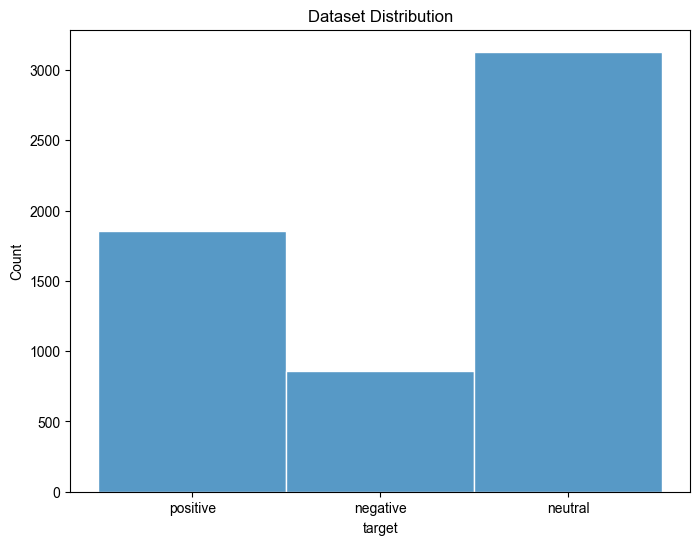

In [10]:
plt.figure(figsize=(8,6))
plt.title('Dataset Distribution')
sns.set(color_codes=True)
sns.set(style="dark", palette="muted")
sns.histplot(df['target'])
plt.show()

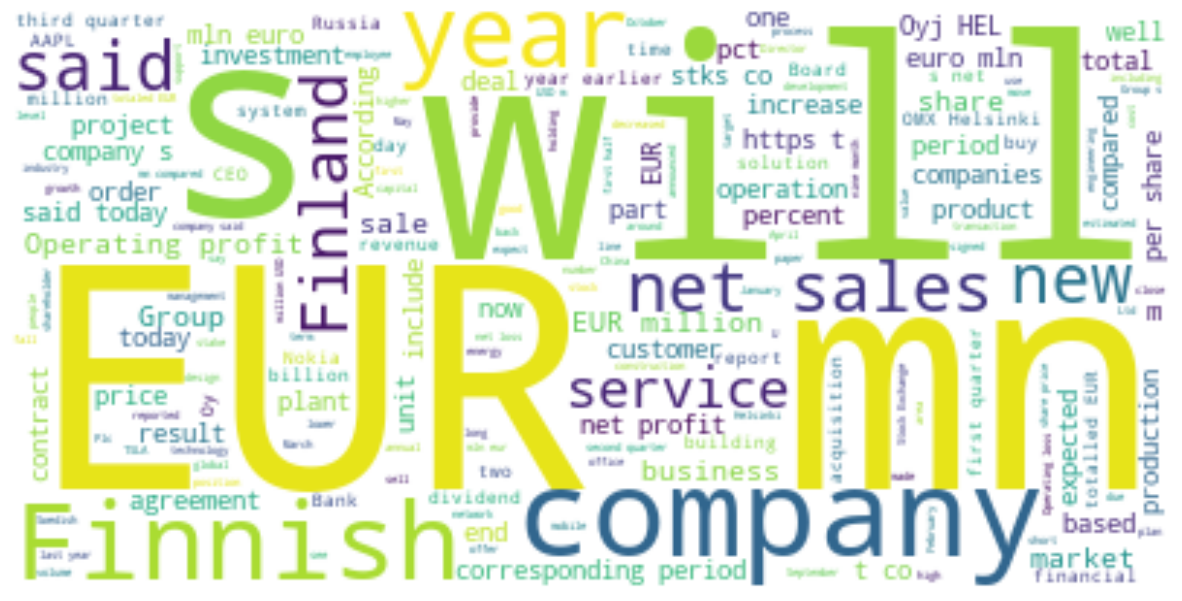

In [11]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from wordcloud import ImageColorGenerator
text = " ".join(i for i in df.data)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [12]:
df['target'] = df['target'].map({'negative': -1, 'neutral': 0, 'positive': 1}) #changing the values of the "target" column to integers

In [13]:
df.head(7)

,data,target
0,The GeoSolutions technology will leverage Bene...,1
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",-1
2,"For the last quarter of 2010 , Componenta 's n...",1
3,According to the Finnish-Russian Chamber of Co...,0
4,The Swedish buyout firm has sold its remaining...,0
5,$SPY wouldn't be surprised to see a green close,1
6,Shell's $70 Billion BG Deal Meets Shareholder ...,-1


# **Data Pre-Processing**

In [14]:
def clean_text(text):
  '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
  # make text lowercase
  text = text.lower()
  # removing text within brackets
  text = re.sub('\[.*?\]', '', text)
  # removing text within parentheses
  text = re.sub('\(.*?\)', '', text)
  # removing numbers
  text = re.sub('\w*\d\w*', '', text)
  # if there's more than 1 whitespace, then make it just 1
  text = re.sub('\s+', ' ', text)
  # if there's a new line, then make it a whitespace
  text = re.sub('\n', ' ', text)
  # removing any quotes
  text = re.sub('\"+', '', text)
  # removing &amp;
  text = re.sub('(\&amp\;)', '', text)
  # removing any usernames
  text = re.sub('(@[^\s]+)', '', text)
  # removing any hashtags
  text = re.sub('(#[^\s]+)', '', text)
  # remove `rt` for retweet
  text = re.sub('(rt)', '', text)
  # string.punctuation is a string of all punctuation marks
  # so this gets rid of all punctuation
  text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
  # getting rid of `httptco`
  text = re.sub('(httptco)', '', text)

  return text

round = lambda x: clean_text(x)

<>:6: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\&'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\('
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\&'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\capra\AppData\Local\Temp\ipykernel_18220\2247866622.py:6: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
C:\Users\capra\AppData\Local\Temp\ipykernel_18220\2247866622.py:8: SyntaxWarning: invalid escape sequence '\('
  text = re.sub('\(.*?\)', '', 

In [15]:
df['data'] = df['data'].apply(clean_text)
df.head(7)

,data,target
0,the geosolutions technology will leverage bene...,1
1,esi on lows down to bk a real possibility,-1
2,for the last quaer of componenta s net sales ...,1
3,according to the finnishrussian chamber of com...,0
4,the swedish buyout firm has sold its remaining...,0
5,spy wouldnt be surprised to see a green close,1
6,shells billion bg deal meets shareholder skep...,-1


In [16]:
#tokenization with stopwords removing
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
def process_text(text):
  tokens = nltk.word_tokenize(text)
  removed_stopwords = [token.lower() for token in tokens if token.lower() not in stop_words]
  return removed_stopwords

In [17]:
import nltk
nltk.download('punkt_tab')
processed_data = list(map(process_text, df['data']))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\capra/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [18]:
processed_data

[['geosolutions',
  'technology',
  'leverage',
  'benefon',
  'gps',
  'solutions',
  'providing',
  'location',
  'based',
  'search',
  'technology',
  'communities',
  'platform',
  'location',
  'relevant',
  'multimedia',
  'content',
  'new',
  'powerful',
  'commercial',
  'model'],
 ['esi', 'lows', 'bk', 'real', 'possibility'],
 ['last',
  'quaer',
  'componenta',
  'net',
  'sales',
  'doubled',
  'period',
  'year',
  'earlier',
  'moved',
  'zero',
  'pretax',
  'profit',
  'pretax',
  'loss'],
 ['according',
  'finnishrussian',
  'chamber',
  'commerce',
  'major',
  'construction',
  'companies',
  'finland',
  'operating',
  'russia'],
 ['swedish',
  'buyout',
  'firm',
  'sold',
  'remaining',
  'percent',
  'stake',
  'almost',
  'eighteen',
  'months',
  'taking',
  'company',
  'public',
  'finland'],
 ['spy', 'wouldnt', 'surprised', 'see', 'green', 'close'],
 ['shells', 'billion', 'bg', 'deal', 'meets', 'shareholder', 'skepticism'],
 ['ssh',
  'communications',
  's

In [19]:
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words("english"))

all_words = " ".join(df["data"]).lower().split()

filtered_words = [
    word
    for word in all_words
    if word not in stop_words
]

Counter(filtered_words).most_common(20)

[('eur', 1273),
 ('company', 809),
 ('mn', 724),
 ('profit', 568),
 ('sales', 559),
 ('finnish', 526),
 ('said', 516),
 ('net', 499),
 ('million', 482),
 ('operating', 371),
 ('year', 340),
 ('period', 331),
 ('group', 323),
 ('finland', 315),
 ('quaer', 312),
 ('share', 288),
 ('new', 274),
 ('mln', 271),
 ('oyj', 250),
 ('business', 244)]

In [20]:
#positive labels
pos_words = " ".join(df[df["target"]==1]["data"]).lower().split()

pos_filtered_words = [
    word
    for word in pos_words
    if word not in stop_words
]

Counter(pos_filtered_words).most_common(20)

[('eur', 435),
 ('mn', 239),
 ('sales', 215),
 ('company', 203),
 ('profit', 202),
 ('net', 197),
 ('said', 194),
 ('finnish', 177),
 ('million', 162),
 ('year', 149),
 ('period', 140),
 ('operating', 120),
 ('quaer', 112),
 ('mln', 103),
 ('group', 98),
 ('new', 96),
 ('rose', 92),
 ('increased', 89),
 ('share', 83),
 ('oyj', 83)]

In [21]:
#negative labels
neg_words = " ".join(df[df["target"]==-1]["data"]).lower().split()

neg_filtered_words = [
    word
    for word in neg_words
    if word not in stop_words
]

Counter(neg_filtered_words).most_common(20)

[('eur', 310),
 ('mn', 220),
 ('profit', 154),
 ('sales', 105),
 ('net', 100),
 ('finnish', 89),
 ('operating', 89),
 ('company', 80),
 ('period', 79),
 ('quaer', 77),
 ('million', 77),
 ('year', 72),
 ('loss', 70),
 ('said', 64),
 ('compared', 62),
 ('decreased', 61),
 ('first', 57),
 ('share', 48),
 ('oyj', 48),
 ('mln', 47)]

In [22]:
#neutral labels
neu_words = " ".join(df[df["target"]==0]["data"]).lower().split()

neu_filtered_words = [
    word
    for word in neu_words
    if word not in stop_words
]

Counter(neu_filtered_words).most_common(20)

[('eur', 528),
 ('company', 526),
 ('mn', 265),
 ('finnish', 260),
 ('said', 258),
 ('million', 243),
 ('sales', 239),
 ('finland', 219),
 ('profit', 212),
 ('net', 202),
 ('group', 196),
 ('shares', 172),
 ('business', 169),
 ('new', 164),
 ('operating', 162),
 ('share', 157),
 ('market', 137),
 ('services', 134),
 ('also', 134),
 ('quaer', 123)]

In [23]:
#lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_output = []
for listy in processed_data:
  lemmed = ' '.join([lemmatizer.lemmatize(w) for w in listy])
  lemmatized_output.append(lemmed)

In [24]:
X_lem = lemmatized_output
y_lem = df['target']

In [25]:
###uncomment for loading models for deployment
pickle_bool=True

# **Train-Test Split (Tf-idf) Vectorization**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_lem, y_lem, test_size=0.20, random_state=15)

In [27]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
)

In [28]:
X_train = tfidf.fit_transform(X_train).toarray()
X_test = tfidf.transform(X_test).toarray()
if pickle_bool:
    with open("models/tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(tfidf, f)

# **Train-Test Split (WordToVec) Vectorization**

In [29]:
from gensim.models import Word2Vec
w2v_model = Word2Vec(
    processed_data,
    vector_size=100,
    window=5,
    min_count=1
)
if pickle_bool:
    w2v_model.save("models/word2vec.model")
def sentence_embedding(tokens):

    vectors = [
        w2v_model.wv[word]
        for word in tokens
        if word in w2v_model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)

    return np.mean(vectors, axis=0)

In [30]:
X_w2v = [
    sentence_embedding(tokens)
    for tokens in processed_data
]

In [31]:
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y_lem, test_size=0.20, random_state=15)

# **Training Functions**

In [32]:
def print_metrics(y_test,y_pred):
    m_precision = precision_score(y_test, y_pred, average='micro')
    m_recall = recall_score(y_test, y_pred, average='micro')
    m_f1_score = f1_score(y_test, y_pred, average='micro')
    m_weighted_f1_score = f1_score(y_test, y_pred, average='weighted')
    m_acc1 = accuracy_score(y_test, y_pred)
    print('Testing Metrics:')
    print('Precision: {:.4}'.format(m_precision))
    print('Recall: {:.4}'.format(m_recall))
    print('F1 Score: {:.4}'.format(m_f1_score))
    print('Weighted F1 Score: {:.4}'.format(m_weighted_f1_score))
    print('Accuracy Score: {:.4}'.format(m_acc1))
    return {'precision': m_precision, 'recall': m_recall, 'f1_score': m_f1_score, 'weighted_f1': m_weighted_f1_score, 'accuracy': m_acc1}
    
    

In [33]:
def naive_bayes_train(X_train,y_train,X_test,y_test):
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    metric_dict_entry=print_metrics(y_test, y_pred)
    return metric_dict_entry

In [34]:
def logistic_reg_train(X_train,y_train,X_test,y_test,pickle_bool=False):
    regression = LogisticRegression(solver='lbfgs', max_iter=5000, C=2.0, class_weight='balanced')
    regression.fit(X_train, y_train)
    if pickle_bool:
        with open("models/logistic_regression.pkl", "wb") as f:
            pickle.dump(regression, f)
    predicts = regression.predict(X_test)
    metric_dict_entry=print_metrics(y_test,predicts)
    return metric_dict_entry

In [35]:
def xgboost_train(X_train,y_train,X_test,y_test):
    # converting labels [-1,0,1] to [0,1,2] for xgboost compatibility
    label_map = {
        -1: 0,
         0: 1,
         1: 2
    }
    
    y_train_xgb = y_train.map(label_map)
    y_test_xgb = y_test.map(label_map)
    classifier = XGBClassifier()
    classifier.fit(X_train, y_train_xgb)
    preds = classifier.predict(X_test)
    metric_dict_entry=print_metrics(y_test, preds)
    return metric_dict_entry


In [36]:
metric_dict={}

# **Models( NB, LR)**

In [37]:
from sklearn.naive_bayes import GaussianNB
metric_dict['Naive Bayes(Tf-idf)']=naive_bayes_train(X_train,y_train,X_test,y_test)

Testing Metrics:
Precision: 0.5167
Recall: 0.5167
F1 Score: 0.5167
Weighted F1 Score: 0.5325
Accuracy Score: 0.5167


In [38]:
metric_dict['Logistic Regression(Tf-idf)']=logistic_reg_train(X_train,y_train,X_test,y_test,pickle_bool)

Testing Metrics:
Precision: 0.6732
Recall: 0.6732
F1 Score: 0.6732
Weighted F1 Score: 0.6811
Accuracy Score: 0.6732


In [39]:
metric_dict['Logistic Regression(w2v)']=logistic_reg_train(X_train_w2v,y_train_w2v,X_test_w2v,y_test_w2v)

Testing Metrics:
Precision: 0.4388
Recall: 0.4388
F1 Score: 0.4388
Weighted F1 Score: 0.4393
Accuracy Score: 0.4388


# **LSTM**

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = df["data"]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
if pickle_bool:
    with open("models/tokenizer.pkl", "wb") as f:
        pickle.dump(tokenizer, f)
X_lstm = tokenizer.texts_to_sequences(texts)
X_lstm = pad_sequences(X_lstm,maxlen=128,padding="post")
vocab_size = len(tokenizer.word_index) + 1

In [41]:

embedding_matrix = np.zeros((vocab_size, 300))

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        vec = w2v_model.wv[word]
        if len(vec) == 100:
            embedding_matrix[idx][:100] = vec


In [42]:
embedding_matrix = np.zeros((vocab_size,100))
for word, idx in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
if pickle_bool:
    torch.save(
    embedding_matrix,
    "models/embedding_matrix.pt")

NameError: name 'torch' is not defined

In [ ]:

import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=3):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=False
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)


In [ ]:
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split( X_lstm, y_lem, test_size=0.2, random_state=42)
label_map = {
    -1: 0,
     0: 1,
     1: 2
}

y_train_lstm = y_train_lstm.map(label_map)
y_test_lstm = y_test_lstm.map(label_map)

In [ ]:
def plot_train_test_losses(train_losses,test_losses, epoch):
    plt.figure(figsize=(8,5))
    
    plt.plot(
        range(1, epoch+1),
        train_losses,
        label="J_train"
    )
    
    plt.plot(
        range(1, epoch+1),
        test_losses,
        label="J_test"
    )
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid()
    
    plt.show()

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
#1,13,16,17

epoch:0, loss:0.9744
epoch:1, loss:0.8733
epoch:2, loss:0.7391
epoch:3, loss:0.6039
epoch:4, loss:0.4736
epoch:5, loss:0.3025
epoch:6, loss:0.2342
epoch:7, loss:0.1860
epoch:8, loss:0.1751
Testing Metrics:
Precision: 0.71
Recall: 0.71
F1 Score: 0.71
Weighted F1 Score: 0.6953
Accuracy Score: 0.71


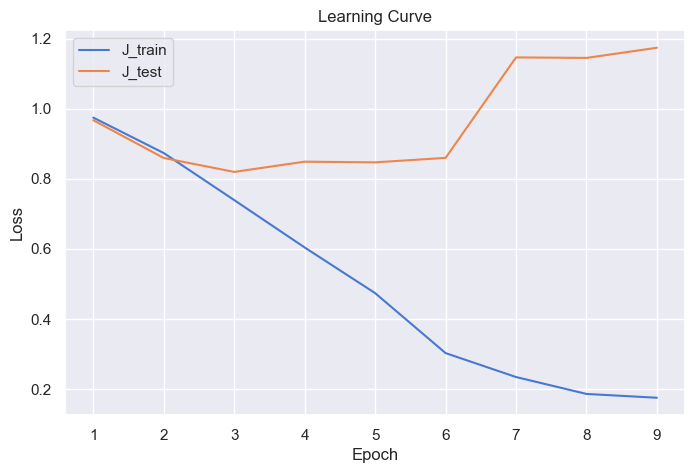

0.7100085543199316


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
def train_infer_lstm(X_train_lstm, y_train_lstm, epoch=20, step=1, pickle_bool=False):
    set_seed(13)
    model = LSTMClassifier(vocab_size)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    X_train_tensor = torch.LongTensor(X_train_lstm)
    y_train_tensor = torch.LongTensor(y_train_lstm)

    loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=64,
        shuffle=True
    )

    train_losses=[]
    test_losses=[]

    model.train()
    for i in range(epoch):
        total_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if i % step == 0:
            print(f"epoch:{i}, loss:{total_loss/len(loader):.4f}")
        avg_train_loss=total_loss/len(loader)

        model.eval()
        with torch.no_grad():
            test_outputs = model(torch.LongTensor(X_test_lstm))
            test_loss = criterion(
                test_outputs,
                torch.LongTensor(y_test_lstm.values)
            ).item()
        train_losses.append(avg_train_loss)
        test_losses.append(test_loss)
    if pickle_bool:
        torch.save(model.state_dict(), "models/lstm_model.pth")
    final_test_outputs = test_outputs.argmax(dim=1).cpu().numpy()
    metric_dict['lstm'] = print_metrics(y_test_lstm, final_test_outputs)
    plot_train_test_losses(train_losses,test_losses, epoch)
    return metric_dict['lstm']['accuracy']
    
acc = train_infer_lstm(X_train_lstm,y_train_lstm,epoch=9,step=1,pickle_bool=pickle_bool)
print(acc)

# **FinBERT**

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import pipeline

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
classifier = pipeline("text-classification",model=model,tokenizer=tokenizer)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
#we only need y_train, y_test, just making sure random state is the same
X_train_FinBERT, X_test_FinBERT, y_train_FinBERT, y_test_FinBERT = train_test_split(X_lem, y_lem, test_size=0.20, random_state=15)
label_map = {
    -1: 0,
     0: 1,
     1: 2
}
y_train_FinBERT= y_train_FinBERT.map(label_map)
y_test_FinBERT = y_test_FinBERT.map(label_map)

In [ ]:
string_map={
    "negative": 0,
     "neutral": 1,
     "positive": 2
}
preds = []
for text in X_test_FinBERT:
    result = classifier(text.lower())[0]
    preds.append(string_map[result["label"]])
metric_dict['FinBERT']=print_metrics(y_test_FinBERT,preds)

Testing Metrics:
Precision: 0.6296
Recall: 0.6296
F1 Score: 0.6296
Weighted F1 Score: 0.618
Accuracy Score: 0.6296


# **Results**

In [ ]:
pd.DataFrame.from_dict(metric_dict, orient='index')

,precision,recall,f1_score,weighted_f1,accuracy
Naive Bayes(Tf-idf),0.516681,0.516681,0.516681,0.532545,0.516681
Logistic Regression(Tf-idf),0.673225,0.673225,0.673225,0.681146,0.673225
Logistic Regression(w2v),0.430282,0.430282,0.430282,0.428729,0.430282
lstm,0.703165,0.703165,0.703165,0.704469,0.703165
FinBERT,0.629598,0.629598,0.629598,0.618050,0.629598
